# ECDSA Nonce Reuse: Recovering Private Key from Two Signatures

# 1. Elliptic Curve Cryptography (ECC) Fundamentals

## 1.1. Đường cong Elliptic là gì?
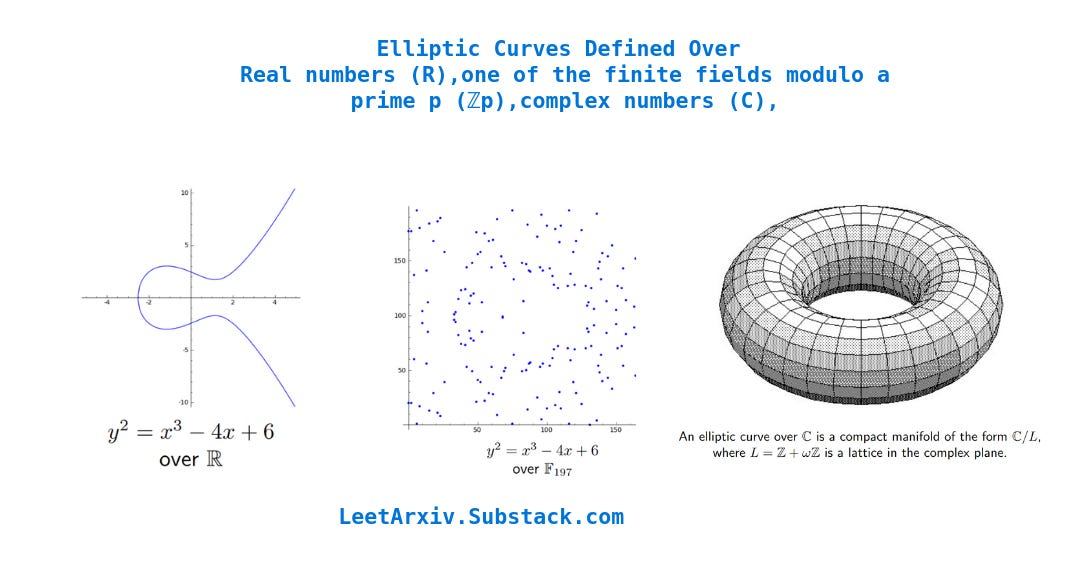
### Tại sao cần biết?

Mỗi khi kết nối HTTPS, SSH, hay ký transaction trên blockchain - ta đang dùng **Elliptic Curve Cryptography (ECC)**. Hiểu ECC giúp ta hiểu tại sao private key bị lộ khi nonce bị reuse.


### Phương trình cơ bản

Một elliptic curve có dạng:

$$y^2 = x^3 + ax + b$$

Với điều kiện $4a^3 + 27b^2 \neq 0$ để curve là **non-singular** (không có cusp hay node).

**Ví dụ:** Curve đơn giản $y^2 = x^3 + 9x + 1$

### Curve trên trường hữu hạn

Trong crypto, ta không dùng số thực mà dùng **số nguyên mod p** (với p là số nguyên tố lớn):

$$y^2 \equiv x^3 + ax + b \pmod{p}$$

**Ví dụ với p = 61:**

| x | $x^3 + 9x + 1 \mod 61$ | $y^2 \mod 61$ | Điểm hợp lệ? |
|---|------------------------|---------------|--------------|
| 0 | $0 + 0 + 1 = 1$ | $1^2 = 1$ ✓ | (0, 1), (0, 60) |
| 1 | $1 + 9 + 1 = 11$ | Không có y | ✗ |
| 2 | $8 + 18 + 1 = 27$ | $16^2 = 256 \equiv 27$ ✓ | (2, 16), (2, 45) |

---

> Trên số thực, curve là đường cong liên tục. Trên $\mathbb{F}_p$, curve chỉ là **tập hợp các điểm rời rạc**.

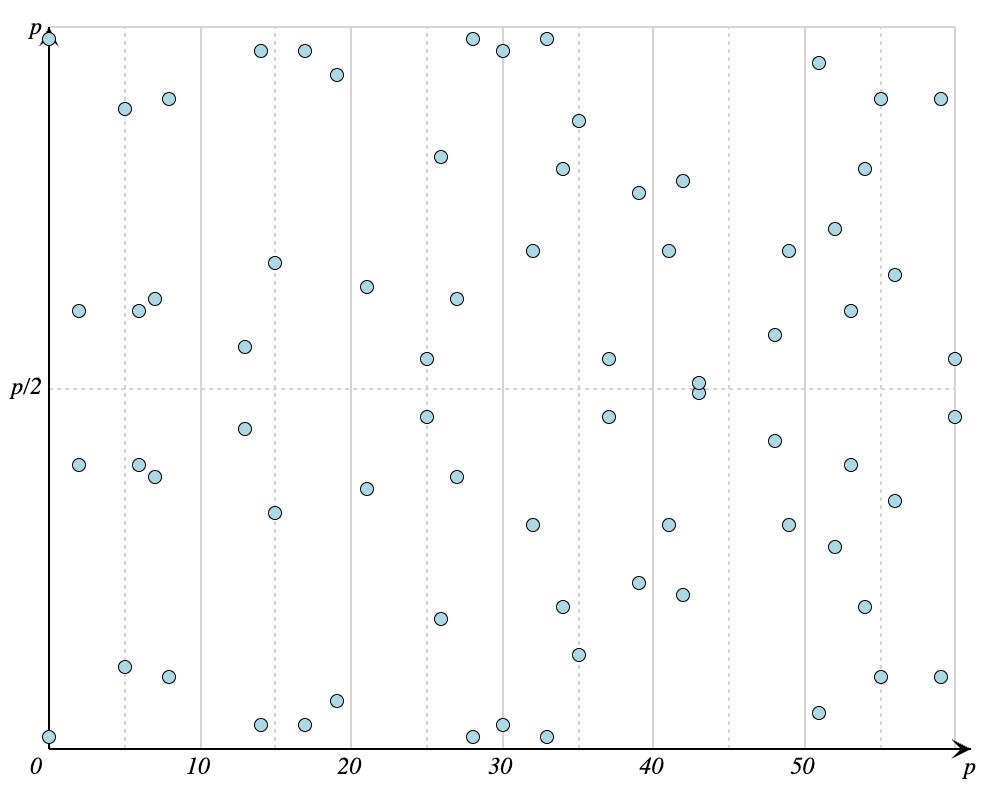

### Các curve phổ biến trong thực tế

| Curve | Sử dụng | Tham số | p |
|-------|---------|---------|---|
| **secp256k1** | Bitcoin, Ethereum | $y^2 = x^3 + 7$ | $2^{256} - 2^{32} - 977$ |
| **P-256** | TLS, HTTPS | $y^2 = x^3 - 3x + b$ | $2^{256} - 2^{224} + 2^{192} + 2^{96} - 1$ |
| **Curve25519** | Signal, SSH | Montgomery curve | $2^{255} - 19$ |


### Điểm vô cực $\mathcal{O}$

Ngoài các điểm $(x, y)$, curve còn có một điểm đặc biệt gọi là **point at infinity** $\mathcal{O}$. 

Vai trò của nó giống phần tử đơn vị trong phép cộng: $P + \mathcal{O} = P$

## 1.2. Phép cộng điểm (Point Addition)

Tập hợp các điểm trên elliptic curve tạo thành một **nhóm Abel** (Abelian group) với phép cộng. Đây là nền tảng toán học cho mọi thuật toán ECC.

### Quy tắc hình học

Cho hai điểm $P$ và $Q$ trên curve, phép cộng $P + Q = R$ được định nghĩa:

1. Vẽ đường thẳng qua $P$ và $Q$
2. Đường thẳng cắt curve tại điểm thứ ba $R'$
3. Phản xạ $R'$ qua trục hoành → được $R$

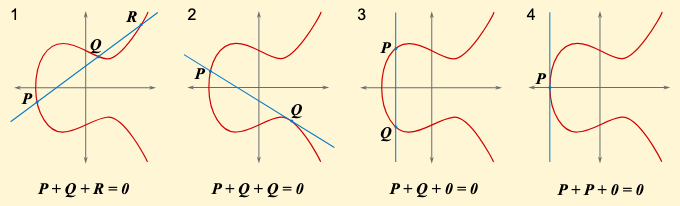

https://curves.xargs.org

### Công thức đại số

**Point Addition** $(P \neq Q)$: Cho $P = (x_1, y_1)$ và $Q = (x_2, y_2)$

$$\lambda = \frac{y_2 - y_1}{x_2 - x_1}$$

$$x_3 = \lambda^2 - x_1 - x_2 \quad,\quad y_3 = \lambda(x_1 - x_3) - y_1$$

**Point Doubling** $(P = Q)$: Cho $P = (x_1, y_1)$

$$\lambda = \frac{3x_1^2 + a}{2y_1}$$

$$x_3 = \lambda^2 - 2x_1 \quad,\quad y_3 = \lambda(x_1 - x_3) - y_1$$

### Các trường hợp đặc biệt

| Phép toán | Kết quả | Giải thích |
|-----------|---------|------------|
| $P + \mathcal{O}$ | $P$ | $\mathcal{O}$ là identity element |
| $P + (-P)$ | $\mathcal{O}$ | Với $-P = (x, -y)$ là inverse |
| $P + P$ | $2P$ | Point doubling (dùng tiếp tuyến) |

### Trên trường hữu hạn $\mathbb{F}_p$

Công thức giữ nguyên, chỉ thay phép chia bằng **modular inverse**:

$$\frac{a}{b} \longrightarrow a \cdot b^{-1} \pmod{p}$$

Trong đó $b^{-1}$ tính bằng **Extended Euclidean Algorithm** hoặc **Fermat's Little Theorem**:

$$b^{-1} \equiv b^{p-2} \pmod{p}$$

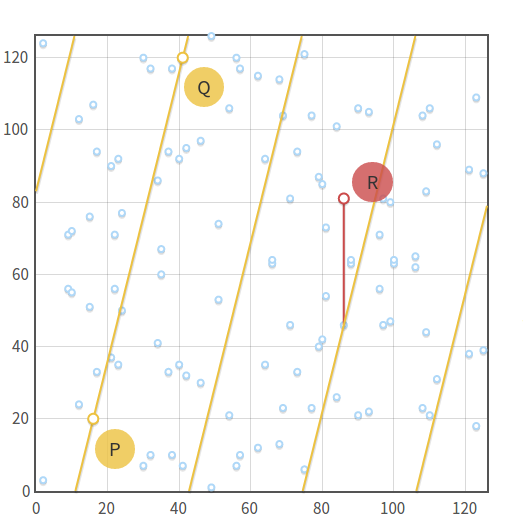
$$E : y^2 = x^3 - x + 3 (mod 127), P(16, 20) , Q (41, 120),P+Q=R$$

### Ví dụ tính toán

Curve: $y^2 = x^3 - x + 3$ trên $\mathbb{F}_{127}$ (tức $a = -1, b = 3$)

Cho $P = (16, 20)$ và $Q = (41, 120)$, tính $R = P + Q$

**Bước 1:** Tính $\lambda$

$$\lambda = (y_2 - y_1) \cdot (x_2 - x_1)^{-1} \pmod{127}$$

$$\lambda = (120 - 20) \cdot (41 - 16)^{-1} = 100 \cdot 25^{-1} \pmod{127}$$

**Bước 2:** Tính modular inverse $25^{-1} \pmod{127}$

Dùng Fermat's Little Theorem: $25^{-1} \equiv 25^{125} \equiv 61 \pmod{127}$

$$\lambda = 100 \cdot 61 = 6100 \equiv 4 \pmod{127}$$

**Bước 3:** Tính tọa độ $R$

$$x_3 = \lambda^2 - x_1 - x_2 = 4^2 - 16 - 41 = -41 \equiv 86 \pmod{127}$$

$$y_3 = \lambda(x_1 - x_3) - y_1 = 4(16 - 86) - 20 = -300 \equiv 81 \pmod{127}$$

$$\boxed{R = P + Q = (86, 81)}$$




In [2]:
p = 127
F = GF(p)
E = EllipticCurve(F, [-1, 3])  # y^2 = x^3 - x + 3

P = E(16, 20)
Q = E(41, 120)
R = P + Q

print(f"P = {P}")
print(f"Q = {Q}")
print(f"P + Q = {R}")  # Expected: (86 : 81 : 1)

P = (16 : 20 : 1)
Q = (41 : 120 : 1)
P + Q = (86 : 81 : 1)


## 1.3. Phép nhân vô hướng (Scalar Multiplication)

Scalar multiplication là phép toán cốt lõi trong ECC - nền tảng để tạo public key từ private key.

### Định nghĩa

Cho điểm $P$ trên curve và số nguyên $k$, phép nhân vô hướng được định nghĩa:

$$k \cdot P = \underbrace{P + P + \cdots + P}_{k \text{ lần}}$$

**Ví dụ:**
- $2P = P + P$
- $5P = P + P + P + P + P$

### Double-and-Add Algorithm

Thay vì cộng $k$ lần (quá chậm với $k$ lớn), ta dùng thuật toán **double-and-add**:

Biểu diễn $k$ dưới dạng binary, ví dụ $k = 21 = (10101)_2$:

$$21 \cdot P = 2^4 \cdot P + 2^2 \cdot P + 2^0 \cdot P = 16P + 4P + P$$

| Bước | Binary bit | Phép toán | Kết quả |
|------|------------|-----------|---------|
| 1 | 1 | $R = P$ | $P$ |
| 2 | 0 | $R = 2R$ | $2P$ |
| 3 | 1 | $R = 2R + P$ | $5P$ |
| 4 | 0 | $R = 2R$ | $10P$ |
| 5 | 1 | $R = 2R + P$ | $21P$ |

**Độ phức tạp:** $O(\log k)$ thay vì $O(k)$

### Ứng dụng: Key Generation

Trong ECC, một cặp khóa được tạo như sau:

$$\text{Private key: } d \quad (\text{số nguyên ngẫu nhiên})$$

$$\text{Public key: } Q = d \cdot G$$

Trong đó $G$ là **generator point** (base point) - một điểm cố định trên curve.

### One-way Function

**Dễ:** Biết $d$ và $G$ → tính $Q = d \cdot G$ (polynomial time)

**Khó:** Biết $Q$ và $G$ → tìm $d$ (Elliptic Curve Discrete Logarithm Problem - **ECDLP**)

> Với curve 256-bit, việc tìm $d$ từ $Q$ và $G$ là **computationally infeasible** - đây là nền tảng bảo mật của ECC.

### Ví dụ

Curve: $y^2 = x^3 - x + 3$ trên $\mathbb{F}_{127}$

Generator: $G = (16, 20)$

Private key: $d = 7$

Public key: $Q = 7 \cdot G = ?$

| $k$ | $k \cdot G$ |
|-----|-------------|
| 1 | $(16, 20)$ |
| 2 | $(43, 99)$ |
| 3 | $(71, 48)$ |
| 4 | $(5, 28)$ |
| 5 | $(80, 10)$ |
| 6 | $(45, 97)$ |
| 7 | $(82, 73)$ |

$$Q = 7G = (82, 73)$$


In [3]:
# Curve y^2 = x^3 - x + 3 trên F_127
p = 127
F = GF(p)
E = EllipticCurve(F, [-1, 3])

# Generator point
G = E(16, 20)

show(f"Curve: {E}")
print(f"Generator G = {G}")
print(f"Order of G: {G.order()}")
print()

# Tính k*G với k từ 1 đến 7
print("Scalar Multiplication:")
for k in range(1, 8):
    kG = k * G
    print(f"  {k}G = {kG}")

print()

# Key Generation
d = 7  # Private key
Q = d * G  # Public key

print(f"Private key d = {d}")
print(f"Public key Q = d*G = {Q}")
print()

# Double-and-Add thủ công cho k = 7 = (111)_2
print("Double-and-Add cho 7G:")
print("  7 = (111)_2")
R = G          # bit đầu = 1 → R = G
print(f"  Bit 1: R = G = {R}")
R = 2*R + G    # bit 2 = 1 → double rồi add
print(f"  Bit 1: R = 2R + G = {R}")
R = 2*R + G    # bit 3 = 1 → double rồi add  
print(f"  Bit 1: R = 2R + G = {R}")


'Curve: Elliptic Curve defined by y^2 = x^3 + 126*x + 3 over Finite Field of size 127'

Generator G = (16 : 20 : 1)
Order of G: 37

Scalar Multiplication:
  1G = (16 : 20 : 1)
  2G = (97 : 81 : 1)
  3G = (84 : 26 : 1)
  4G = (57 : 10 : 1)
  5G = (15 : 51 : 1)
  6G = (41 : 120 : 1)
  7G = (86 : 81 : 1)

Private key d = 7
Public key Q = d*G = (86 : 81 : 1)

Double-and-Add cho 7G:
  7 = (111)_2
  Bit 1: R = G = (16 : 20 : 1)
  Bit 1: R = 2R + G = (84 : 26 : 1)
  Bit 1: R = 2R + G = (86 : 81 : 1)


## 1.4. Elliptic Curve Discrete Logarithm Problem (ECDLP)

ECDLP là nền tảng bảo mật của toàn bộ hệ thống ECC. Nếu ECDLP bị phá vỡ, mọi hệ thống dựa trên ECC (ECDSA, ECDH, ...) đều sụp đổ.

### Định nghĩa

Cho curve $E$ trên $\mathbb{F}_p$, điểm $G$ (generator), và điểm $Q$ trên curve:

$$\text{Tìm } d \text{ sao cho } Q = d \cdot G$$

**Input:** $E$, $G$, $Q$

**Output:** $d$ (discrete logarithm của $Q$ theo cơ số $G$)

### Tại sao khó?

| Hướng | Độ phức tạp | Với 256-bit curve |
|-------|-------------|-------------------|
| $d, G \rightarrow Q$ | $O(\log d)$ | Microseconds |
| $Q, G \rightarrow d$ | $O(\sqrt{n})$ best known | $2^{128}$ operations |

--

> Với $2^{128}$ operations, ngay cả supercomputer cũng cần hàng tỷ năm.

### So sánh với DLP trên $\mathbb{Z}_p^*$

| | DLP trên $\mathbb{Z}_p^*$ | ECDLP |
|---|---------------------------|-------|
| Bài toán | $g^x \equiv h \pmod{p}$, tìm $x$ | $x \cdot G = Q$, tìm $x$ |
| Best attack | Index Calculus $O(e^{\sqrt{\log p}})$ | Pollard's Rho $O(\sqrt{n})$ |
| Key size cho 128-bit security | 3072 bits | 256 bits |

ECDLP không có sub-exponential attack như Index Calculus → ECC cần key ngắn hơn nhiều.

### Các thuật toán tấn công ECDLP

| Thuật toán | Độ phức tạp | Ghi chú |
|------------|-------------|---------|
| Brute force | $O(n)$ | Thử từng $d$ |
| Baby-step Giant-step | $O(\sqrt{n})$ time, $O(\sqrt{n})$ space | Cần nhiều bộ nhớ |
| Pollard's Rho | $O(\sqrt{n})$ time, $O(1)$ space | Phổ biến nhất |
| Pohlig-Hellman | $O(\sqrt{p_i})$ với $p_i$ là prime factors của $n$ | Nguy hiểm nếu $n$ có small factors |

### Điều kiện để curve an toàn

1. **Order $n$ phải là số nguyên tố lớn** (hoặc có large prime factor) - tránh Pohlig-Hellman

2. **$n \neq p$** - tránh Smart's attack (anomalous curves)

3. **$p^k \neq 1 \pmod{n}$ với $k$ nhỏ** - tránh MOV attack

4. **Curve được chọn ngẫu nhiên có thể kiểm chứng** - tránh backdoor (nothing-up-my-sleeve)

### Ví dụ thực tế: secp256k1

p  = 0xFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFEFFFFFC2F

n  = 0xFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFEBAAEDCE6AF48A03BBFD25E8CD0364141


- $n$ là số nguyên tố 256-bit
- $n \approx p$ nhưng $n \neq p$
- Không có known weakness


In [ ]:
p = 0xfffffffffffffffffffffffffffffffffffffffffffffffffffffffefffffc2f
K = GF(p)
a = K(0x0000000000000000000000000000000000000000000000000000000000000000)
b = K(0x0000000000000000000000000000000000000000000000000000000000000007)
E = EllipticCurve(K, (a, b))
G = E(0x79be667ef9dcbbac55a06295ce870b07029bfcdb2dce28d959f2815b16f81798, 0x483ada7726a3c4655da4fbfc0e1108a8fd17b448a68554199c47d08ffb10d4b8)
E.set_order(0xfffffffffffffffffffffffffffffffebaaedce6af48a03bbfd25e8cd0364141 * 0x1)

show(G*65537)

(15918057334216069380007851406267302620904875230138054041416128150917396916342 : 114501073437582511822942718348520153285084189980109520961805885006106925312113 : 1)

115792089237316195423570985008687907853269984665640564039457584007908834671663

-432420386565659656852420866390673177326

# 2. ECDSA (Elliptic Curve Digital Signature Algorithm)

## 2.1. Tổng quan về chữ ký số

### Chữ ký số là gì?

Chữ ký số là cơ chế cho phép:

1. **Authentication** - Xác minh danh tính người ký
2. **Integrity** - Đảm bảo message không bị thay đổi
3. **Non-repudiation** - Người ký không thể phủ nhận đã ký

### Nguyên lý hoạt động

**1. Key Generation**
- Signer tạo cặp khóa: private key $d$, public key $Q = d \cdot G$
- Public key $Q$ được chia sẻ công khai

**2. Signing**
- Signer dùng private key $d$ để ký message $m$
- Output: signature $(r, s)$

**3. Verification**
- Verifier dùng public key $Q$ để kiểm tra signature
- Output: $true$ (hợp lệ) hoặc $false$ (không hợp lệ)

| Bước | Input | Output | Ai thực hiện |
|------|-------|--------|--------------|
| Key Gen | - | $(d, Q)$ | Signer |
| Sign | $m$, $d$ | $(r, s)$ | Signer |
| Verify | $m$, $(r, s)$, $Q$ | $true/false$ | Verifier |


### So sánh các thuật toán chữ ký

| Thuật toán | Dựa trên | Key size (128-bit security) | Signature size |
|------------|----------|----------------------------|----------------|
| RSA | Integer Factorization | 3072 bits | 3072 bits |
| DSA | DLP trên $\mathbb{Z}_p^*$ | 3072 bits | 448 bits |
| **ECDSA** | ECDLP | 256 bits | 512 bits |
| EdDSA | ECDLP (twisted Edwards) | 256 bits | 512 bits |

### Quy trình tổng quát

**Signing:**
$$\sigma = \text{Sign}(m, d)$$

- Input: message $m$, private key $d$
- Output: signature $\sigma$

**Verification:**
$$\{true, false\} = \text{Verify}(m, \sigma, Q)$$

- Input: message $m$, signature $\sigma$, public key $Q$
- Output: hợp lệ hay không

### Tại sao dùng ECDSA?

| Ưu điểm | Giải thích |
|---------|------------|
| Key ngắn | 256-bit vs 3072-bit (RSA) |
| Signature nhỏ | 64 bytes (secp256k1) |
| Nhanh | Ít phép tính hơn RSA |
| Phổ biến | Bitcoin, Ethereum, TLS, SSH |

---

| Nhược điểm | Giải thích |
|------------|------------|
| Cần random nonce | **Nonce reuse → lộ private key** |
| Phức tạp hơn RSA | Cần hiểu ECC |
| Malleable | Signature $(r, s)$ và $(r, n-s)$ đều hợp lệ |



## 2.2. Nguyên lý hoạt động của ECDSA

### Tham số chung

Các bên thống nhất domain parameters $(p, a, b, G, n, h)$ và hash function $H$ (ví dụ SHA-256).

### Bước 1: Key Generation

1. Chọn ngẫu nhiên $d \in [1, n-1]$ → đây là **private key**
2. Tính $Q = d \cdot G$ → đây là **public key**

$$\boxed{d \xrightarrow{\text{scalar mult}} Q = d \cdot G}$$

### Bước 2: Signature Generation

Signer muốn ký message $m$ với private key $d$:

1. Tính hash: $e = H(m)$
2. Chọn ngẫu nhiên $k \in [1, n-1]$ → đây là **nonce**
3. Tính điểm: $R = k \cdot G = (x_R, y_R)$
4. Tính $r = x_R \mod n$. Nếu $r = 0$, quay lại bước 2
5. Tính $s = k^{-1}(e + d \cdot r) \mod n$. Nếu $s = 0$, quay lại bước 2

$$\boxed{s = k^{-1}(e + d \cdot r) \pmod{n}}$$

Signature là cặp $(r, s)$.

> **Chú ý:** Nonce $k$ phải **ngẫu nhiên, bí mật, và không bao giờ được tái sử dụng**. Đây là yếu tố then chốt mà ta sẽ khai thác ở phần 4.

### Bước 3: Signature Verification

Verifier có message $m$, signature $(r, s)$, và public key $Q$:

1. Kiểm tra $r, s \in [1, n-1]$
2. Tính hash: $e = H(m)$
3. Tính $w = s^{-1} \mod n$
4. Tính $u_1 = e \cdot w \mod n$
5. Tính $u_2 = r \cdot w \mod n$
6. Tính điểm: $R' = u_1 \cdot G + u_2 \cdot Q$
7. Signature hợp lệ nếu $x_{R'} \equiv r \pmod{n}$

### Tại sao verification hoạt động?

$$R' = u_1 \cdot G + u_2 \cdot Q$$

Thay $Q = d \cdot G$:

$$R' = u_1 \cdot G + u_2 \cdot d \cdot G = (u_1 + u_2 \cdot d) \cdot G$$

Thay $u_1 = e \cdot s^{-1}$ và $u_2 = r \cdot s^{-1}$:

$$R' = (e \cdot s^{-1} + r \cdot d \cdot s^{-1}) \cdot G = s^{-1}(e + d \cdot r) \cdot G$$

Mà $s = k^{-1}(e + d \cdot r)$ nên $s^{-1}(e + d \cdot r) = k$:

$$R' = k \cdot G = R \quad \checkmark$$





In [9]:
from hashlib import sha1

# --- secp256k1 Parameters ---
p = 0xfffffffffffffffffffffffffffffffffffffffffffffffffffffffefffffc2f
K = GF(p)
a = K(0x0000000000000000000000000000000000000000000000000000000000000000)
b = K(0x0000000000000000000000000000000000000000000000000000000000000007)
E = EllipticCurve(K, (a, b))
G = E(0x79be667ef9dcbbac55a06295ce870b07029bfcdb2dce28d959f2815b16f81798,
      0x483ada7726a3c4655da4fbfc0e1108a8fd17b448a68554199c47d08ffb10d4b8)
n = 0xfffffffffffffffffffffffffffffffebaaedce6af48a03bbfd25e8cd0364141
E.set_order(n * 0x1)

# --- Key Generation ---
d = randint(1, n - 1)
Q = d * G

print(f"Private key d = {hex(d)}")
print(f"Public key  Q = ({hex(Integer(Q[0]))}, {hex(Integer(Q[1]))})")
print()

# --- Hash Function ---
def hash_message(message):
    h = sha1(message.encode()).hexdigest()
    return int(h, 16)

# --- Sign ---
def sign(message, d):
    e = hash_message(message)
    
    while True:
        k = randint(1, n - 1)
        R = k * G
        r = Integer(R[0]) % n
        if r == 0:
            continue
        s = (inverse_mod(k, n) * (e + d * r)) % n
        if s == 0:
            continue
        
        # Encode r||s thành 64 bytes (32 bytes r + 32 bytes s)
        sig = int(r).to_bytes(32, 'big') + int(s).to_bytes(32, 'big')
        return sig

# --- Verify ---
def verify(message, sig, Q):
    # Parse r||s từ 64 bytes
    r = int.from_bytes(sig[:32], 'big')
    s = int.from_bytes(sig[32:], 'big')
    
    if not (1 <= r < n and 1 <= s < n):
        return False
    
    e = hash_message(message)
    w = inverse_mod(s, n)
    u1 = (e * w) % n
    u2 = (r * w) % n
    R_prime = u1 * G + u2 * Q
    
    return Integer(R_prime[0]) % n == r

# --- Demo ---
message = "welcome new cryptographer"

print(f"Message: \"{message}\"")
print(f"SHA-1:   {sha1(message.encode()).hexdigest()}")
print()

# Sign
sig = sign(message, d)
print("--- Signature (r||s) ---")
print(f"hex: {sig.hex()}")
print()
print(f"  r = {sig[:32].hex()}")
print(f"  s = {sig[32:].hex()}")
print()

# Verify
is_valid = verify(message, sig, Q)
print(f"--- Verification ---")
print(f"Valid: {is_valid}")

# Tampered message
is_valid_tampered = verify("welcome new hacker", sig, Q)
print(f"--- Tampered Message ---")
print(f"Valid: {is_valid_tampered}")


Private key d = 0x4f0acbe268d0c568482a220eb57ac149161667d83773f43bb3c6691d2b4bb052
Public key  Q = (0xca1c14bbf8e328d0a7afef8260f1c2720b6376875c94ec55950f043a3a9cba4d, 0xd3a93f34e816738d53c72a0e5803acb8f8d39a0635330a494b50994911356ceb)

Message: "welcome new cryptographer"
SHA-1:   457cb8c2fe3ad0b8f04733b6fabb798bbc12b287

--- Signature (r||s) ---
hex: f1180c8fbd6c062508543227b089602436701f622f31c0523d4cdabe35676293b95dfc32ef3e7cc088dc28c08501b80ad8de253882822b89a43dff0f42dc4a24

  r = f1180c8fbd6c062508543227b089602436701f622f31c0523d4cdabe35676293
  s = b95dfc32ef3e7cc088dc28c08501b80ad8de253882822b89a43dff0f42dc4a24

--- Verification ---
Valid: True
--- Tampered Message ---
Valid: False


# 3. Vai trò của Nonce trong ECDSA

## 3.1. Nonce là gì và tại sao cần nonce?

### Định nghĩa

**Nonce** = **N**umber used **once**. Trong ECDSA, nonce $k$ là số ngẫu nhiên được chọn mỗi lần ký:

$$s = k^{-1}(e + d \cdot r) \pmod{n}$$

### Tại sao cần nonce?

Nếu không có $k$, công thức ký sẽ là:

$$s = e + d \cdot r \pmod{n}$$

Attacker có $e$ (hash công khai), $r$ và $s$ (signature công khai) → giải ra $d$ ngay lập tức. Nonce $k$ đóng vai trò **che giấu private key** $d$ trong phương trình.

### Hình dung đơn giản

Phương trình $s = k^{-1}(e + d \cdot r)$ có **2 ẩn**: $k$ và $d$.

Một phương trình, hai ẩn → **không giải được** → private key $d$ an toàn.

## 3.2. Yêu cầu bảo mật của nonce

| Yêu cầu | Vi phạm → Hậu quả |
|---------|-------------------|
| **Random** | Nonce có thể đoán được → lộ $d$ |
| **Secret** | Nonce bị lộ → lộ $d$ ngay lập tức |
| **Unique** | Nonce bị reuse → lộ $d$ (phần 4) |

### Nếu $k$ bị lộ

Từ $s = k^{-1}(e + d \cdot r) \pmod{n}$, attacker biết $k$, $s$, $e$, $r$ → tính $d$ trực tiếp:

$$d = r^{-1}(s \cdot k - e) \pmod{n}$$

### Nếu $k$ bị reuse

Hai signatures $(r_1, s_1)$ và $(r_2, s_2)$ dùng cùng $k$:
- Cùng $k$ → cùng $R = k \cdot G$ → **cùng $r$**
- Attacker thấy $r_1 = r_2$ → biết ngay nonce bị reuse
- Từ hai phương trình, hai ẩn → **giải được cả $k$ lẫn $d$**

> Chi tiết tấn công sẽ được trình bày ở phần 4.

### Nếu $k$ có bias

Ngay cả khi $k$ không bị reuse nhưng chỉ bị **biased** (ví dụ: vài bit đầu luôn = 0), attacker vẫn có thể dùng **lattice attack** để khôi phục $d$ sau khi thu thập đủ số lượng signatures.

## 3.3. Deterministic Nonce - RFC 6979

### Vấn đề với random nonce

Sinh $k$ ngẫu nhiên phụ thuộc vào chất lượng RNG (Random Number Generator):
- RNG yếu → $k$ có thể đoán được
- RNG lỗi → $k$ bị lặp
- Embedded device → entropy thấp

### Giải pháp: Deterministic nonce

RFC 6979 đề xuất sinh $k$ từ chính message và private key:

$$k = \text{HMAC-DRBG}(d, H(m))$$

| | Random nonce | Deterministic nonce (RFC 6979) |
|---|---|---|
| Input | RNG | $d$ + $H(m)$ |
| Cùng $(d, m)$ | Khác $k$ mỗi lần | Cùng $k$ → cùng signature |
| Phụ thuộc RNG | Có | Không |
| Nonce reuse | Có thể xảy ra nếu RNG lỗi | Chỉ xảy ra khi cùng $(d, m)$ → cùng signature, không lộ thông tin mới |
| Testable | Không (non-deterministic) | Có (deterministic → có thể viết test vector) |

# 4. Nonce Reuse Attack

## 4.1. Mô tả lỗ hổng

### Kịch bản

Signer ký **hai message khác nhau** $m_1$ và $m_2$ bằng cùng private key $d$, nhưng **dùng cùng một nonce** $k$:

| | Signature 1 | Signature 2 |
|---|---|---|
| Message | $m_1$ | $m_2$ |
| Hash | $e_1 = H(m_1)$ | $e_2 = H(m_2)$ |
| Nonce | $k$ | $k$ (reuse!) |
| $R = k \cdot G$ | $(x_R, y_R)$ | $(x_R, y_R)$ — giống nhau |
| $r$ | $r_1$ | $r_2$ |
| $s$ | $s_1$ | $s_2$ |

Vì cùng $k$ → cùng $R$ → **$r_1 = r_2$**

### Attacker quan sát được gì?

Attacker chỉ cần thông tin **công khai**:

| Thông tin | Công khai? |
|-----------|-----------|
| $m_1$, $m_2$ | Có |
| $e_1 = H(m_1)$, $e_2 = H(m_2)$ | Có (tự tính được) |
| $r_1$, $s_1$ | Có (signature công khai) |
| $r_2$, $s_2$ | Có (signature công khai) |
| $r_1 = r_2$ | Dấu hiệu nhận biết nonce reuse |
| $k$ | Không |
| $d$ | Không |

### Dấu hiệu nhận biết

Attacker chỉ cần so sánh giá trị $r$ của các signatures:

$$r_1 = r_2 \implies \text{cùng nonce } k$$

Đây là điều kiện **cần và đủ** (trên thực tế, xác suất hai nonce khác nhau cho cùng $r$ là $\approx 1/n$, không đáng kể).

## 4.2. Phân tích toán học của attack

### Hệ phương trình

Từ hai signatures dùng cùng nonce $k$:

$$s_1 = k^{-1}(e_1 + d \cdot r) \pmod{n} \quad \text{...(1)}$$

$$s_2 = k^{-1}(e_2 + d \cdot r) \pmod{n} \quad \text{...(2)}$$

### Bước 1: Khôi phục nonce $k$

Lấy $(1) - (2)$:

$$s_1 - s_2 = k^{-1}(e_1 + d \cdot r) - k^{-1}(e_2 + d \cdot r) \pmod{n}$$

$$s_1 - s_2 = k^{-1}\big[(e_1 + d \cdot r) - (e_2 + d \cdot r)\big] \pmod{n}$$

$$s_1 - s_2 = k^{-1}(e_1 - e_2) \pmod{n}$$

Giải ra $k$:

$$\boxed{k = (e_1 - e_2) \cdot (s_1 - s_2)^{-1} \pmod{n}}$$

### Bước 2: Khôi phục private key $d$

Từ phương trình $(1)$:

$$s_1 = k^{-1}(e_1 + d \cdot r) \pmod{n}$$

$$s_1 \cdot k = e_1 + d \cdot r \pmod{n}$$

$$d \cdot r = s_1 \cdot k - e_1 \pmod{n}$$

$$\boxed{d = r^{-1}(s_1 \cdot k - e_1) \pmod{n}}$$

### Tóm tắt

Toàn bộ attack chỉ cần **2 bước**, sử dụng hoàn toàn thông tin công khai:

$$k = \frac{e_1 - e_2}{s_1 - s_2} \pmod{n}$$

$$d = \frac{s_1 \cdot k - e_1}{r} \pmod{n}$$

> Không cần brute force, không cần giải ECDLP. Chỉ cần **phép cộng, trừ, nhân, và modular inverse** — hoàn thành trong microseconds.


## 4.3. Case studies thực tế

### Sony PlayStation 3 (2010)

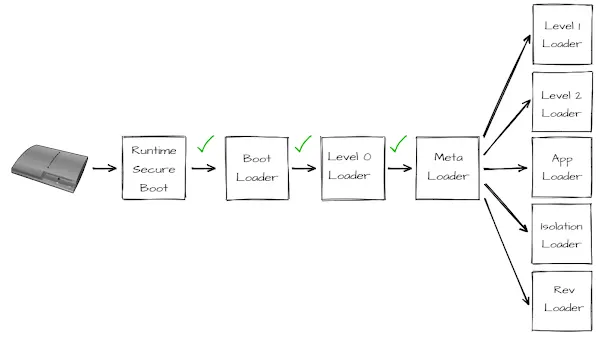

**Sự cố:**
- Sony dùng ECDSA để ký firmware và games cho PS3
- Họ sử dụng **cùng một nonce $k$ cho mọi signature**
- Nhóm hacker fail0verflow phát hiện và công bố private key tại hội nghị 27C3

**Nguyên nhân:**
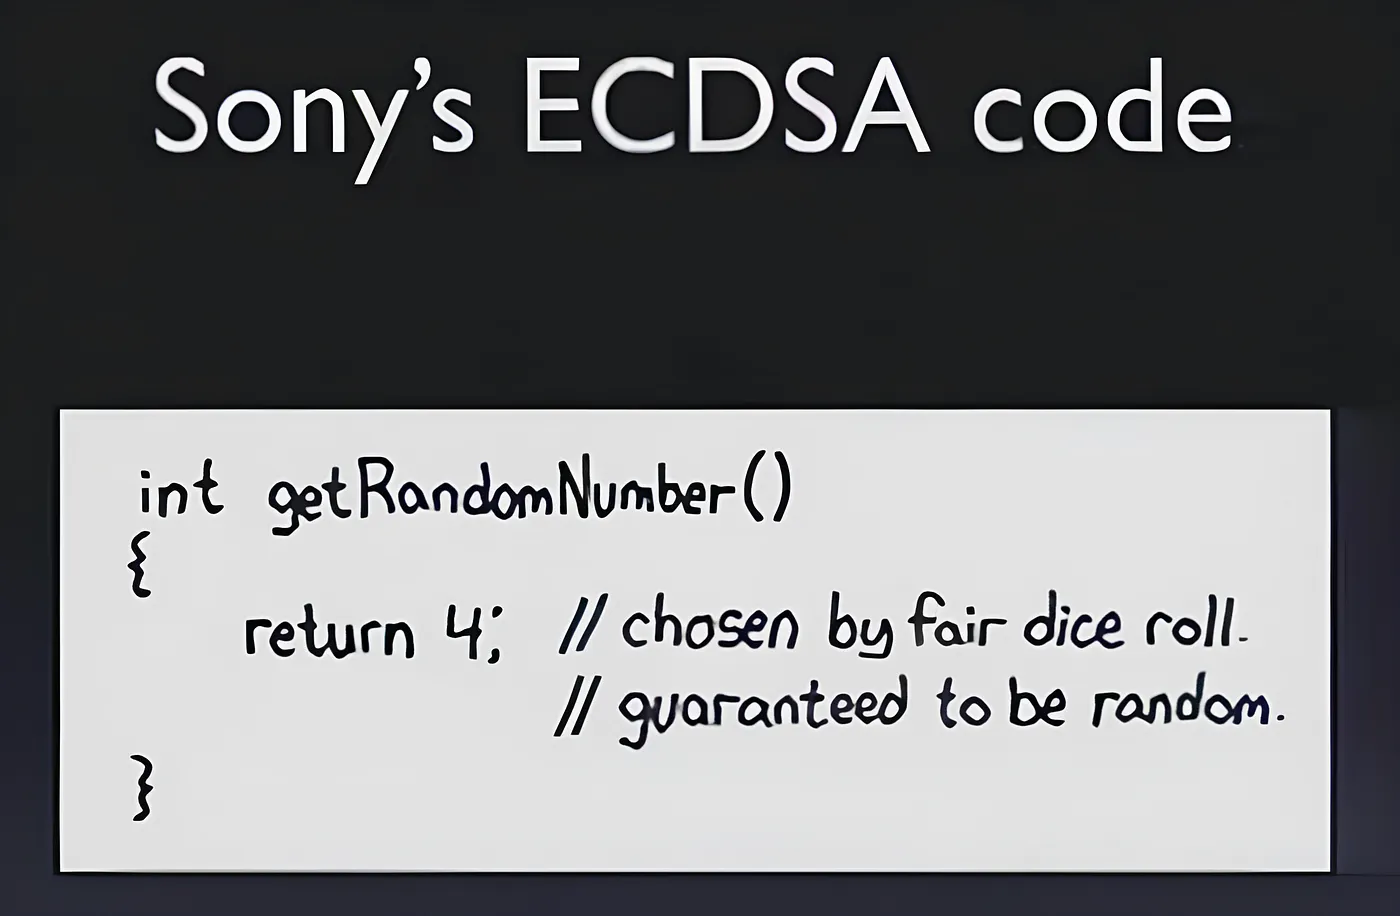
```c
// Code của Sony (pseudocode)
int get_random_number(void) {
    return 4;  // chosen by fair dice roll.
               // guaranteed to be random.
}
```
Sony đã hardcode giá trị "random" thay vì dùng RNG thực sự.

Hậu quả:

Toàn bộ hệ thống bảo mật PS3 sụp đổ
Homebrew software, pirated games chạy tự do
Sony phải kiện fail0verflow nhưng không thể thu hồi private key đã bị leak
Trích dẫn từ fail0verflow:

> "The random number is not random. It's static. It's the same for every signature. [...] You need the private key to make a signature, but because of this epic fail, we can now calculate it."

### Bitcoin & Blockchain (2013)
Sự cố:

* Nhiều Bitcoin wallets dùng weak RNG hoặc reuse nonce
* Researcher Nils Schneider phân tích blockchain, tìm được nhiều transactions có cùng $r$ value

https://blockchain.info/tx/b6350f4339a59faf09bfc2a4086c2261598f46f257517ce53785145c964799bc https://blockchain.info/tx/38fbb8a3ff718dd7c8006feb6aa9ed6add1772522781b0db95abb350a859220b

Kết quả:

* Hàng trăm private keys bị khôi phục
* Số Bitcoin bị đánh cắp ước tính hàng triệu USD

Nguyên nhân phổ biến:

* Android SecureRandom bug (CVE-2013-7372)
* Embedded wallets với entropy thấp
* Copy-paste code không hiểu về crypto


In [16]:
#!/usr/bin/env python3
"""ECDSA Nonce Reuse Solver"""

import json
import hashlib
import secrets
from ecdsa import SECP256k1
from ecdsa.numbertheory import inverse_mod

CURVE = SECP256k1
ORDER = CURVE.order
G = CURVE.generator

def hash_msg(msg: str) -> int:
    return int(hashlib.sha256(msg.encode()).hexdigest(), 16)

# ======================================
# PASTE VALUES FROM CHALLENGE HERE
# ======================================
# TX[0]: Alice -> Bob, value=100
R  = 0x8accf45d1216add63f3525d5781d8f2df649d00c0a1fbfc0015bf23e4044ac0d   # <-- paste r (same for both TX)
S1 = 0xabe0dd22b3e244805260fde5b0b354d34395b254882eea6e2bb060fc6fb30afb   # <-- paste s

# TX[2]: Alice -> Charlie, value=200
S2 = 0x53f23f272fcbda01d0f05688263d0510de11c525f0888c756a27dbede2e9648c   # <-- paste s
# ======================================

MSG1 = '{"from": "Alice", "to": "Bob", "value": 100}'
MSG2 = '{"from": "Alice", "to": "Charlie", "value": 200}'

e1 = hash_msg(MSG1) % ORDER
e2 = hash_msg(MSG2) % ORDER

# Recover private key
k = ((e1 - e2) * inverse_mod(S1 - S2, ORDER)) % ORDER
d = (inverse_mod(R, ORDER) * (S1 * k - e1)) % ORDER

print(f"[+] Recovered Alice's private key:")
print(f"    {hex(d)}")

# Forge signature
TARGET = "Bob"
AMOUNT = 9700  # Alice's balance

msg = '{"from": "Alice", "to": "Bob", "value": 9700}'

e = hash_msg(msg) % ORDER
k_new = secrets.randbelow(ORDER - 1) + 1
r_new = (k_new * G).x() % ORDER
s_new = (inverse_mod(k_new, ORDER) * (e + d * r_new)) % ORDER

print()
print("[+] Forged signature for Alice -> Hacker: $9700")
print()
print("  to: Hacker")
print(f"  value: {AMOUNT}")
print(f"  r: {hex(r_new)}")
print(f"  s: {hex(s_new)}")


[+] Recovered Alice's private key:
    0x9518afef4eeba00ed7e696c955fee6c4ee51457d4468e6fd9cd5149f587555d8

[+] Forged signature for Alice -> Hacker: $9700

  to: Hacker
  value: 9700
  r: 0x45e9d03fe390c94a77f314b393a5826457cb796e46ab5b20ba8a2d85327ed12b
  s: 0x565cfe8493a1ee6da521ace8fdc60f9a5504f0ef7556cc136fa8f404fc88561b


### References
* https://christian-rossow.de/publications/btcsteal-raid2018.pdf
* https://deeprnd.medium.com/decoding-the-playstation-3-hack-unraveling-the-ecdsa-random-generator-flaw-e9074a51b831
* https://freedium-mirror.cfd/https://medium.com/asecuritysite-when-bob-met-alice/not-playing-randomly-the-sony-ps3-and-bitcoin-crypto-hacks-c1fe92bea9bc
* https://fahrplan.events.ccc.de/congress/2010/Fahrplan/attachments/1780_27c3_console_hacking_2010.pdf
* https://web.archive.org/web/20211220154903/https://crypto.stanford.edu/pbc/notes/elliptic/
* https://web.archive.org/web/20180712015726/http://www.nilsschneider.net/2013/01/28/recovering-bitcoin-private-keys.html
* https://curves.xargs.org/
